In [1]:
# 0. 라이브러리 불러오기
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

In [2]:
# 1. 데이터 불러오기

# csv->npy로 수정
x_raw = np.load('X_rank3_tensor.npy')
y_raw = np.load('y_labels.npy')

print(x_raw.shape)
print(y_raw.shape)

(1765, 60, 10)
(1765,)


In [3]:
# 2. input 데이터 전처리

# ----- 1. 특징 그룹 정의 ----- #
track_features = [
		'tempo', 'loudness', 'mode', 'danceability', 'energy',
    'speechiness', 'acousticness', 'liveness', 'happiness', 'instrumentalness'
]

# 수치형
numeric_features = [f for f in track_features if f != 'mode']
# 범주형
categorical_feature = ['mode']



# ----- 2. Scaler, Encoder 초기화 ----- #
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)



# ----- 3. 전처리 함수 정의 ----- #
def data_preprocessed(x_data, is_train=False):
	(n_playlists, n_tracks, n_features) = x_data.shape
  # 3d -> 2d
	x_2d = x_data.reshape(n_playlists*n_tracks, n_features)
	x_df = pd.DataFrame(x_2d, columns=track_features)

	real_song = x_df['tempo'] > 0

	#수치형 전처리
	if is_train:
		scaler.fit(x_df.loc[real_song, numeric_features])

	x_df.loc[real_song, numeric_features] = scaler.transform(
		x_df.loc[real_song, numeric_features]
	)

	#범주형 전처리
	if is_train:
		encoder.fit(x_df.loc[real_song, categorical_feature])

	#전체 변환, 패딩된 노래는 0
	mode_encoded = encoder.transform(x_df[categorical_feature])
	mode_encoded[~real_song] = 0


	# 병합
	x_numeric = x_df[numeric_features].values
	x_2d = np.concatenate([x_numeric, mode_encoded], axis=1)

	# 2d 배열을 다시 3d로 변환
	n_features = x_2d.shape[1]
	x_data = x_2d.reshape(n_playlists, n_tracks, n_features) # 전처리 완료

	return x_data # 전처리 완료 반환

# ----- 4. 전처리 실행 ----- #
x_data = data_preprocessed(x_raw, is_train=True)
print("(전처리완료) x_data shape: ", x_data.shape)


(전처리완료) x_data shape:  (1765, 60, 11)


## 하나의 CNN에서 4개의 출력을 동시에 내는 Multitask

In [4]:
# 3. y라벨링

# y_raw에 대해서 4개의 값을 가지도록 y라벨링
# ex. enfp -> ei=1, sn=1, ft=0, pj=0

import numpy as np

def mbti_to_multitask_label(y_mbti):
    labels = []
    for mbti in y_mbti:
        ei = 1 if mbti[0] == 'E' else 0
        sn = 1 if mbti[1] == 'N' else 0
        ft = 1 if mbti[2] == 'T' else 0
        pj = 1 if mbti[3] == 'J' else 0
        labels.append([ei, sn, ft, pj])
    return np.array(labels)

y_multi = mbti_to_multitask_label(y_raw)

print(y_multi.shape)

(1765, 4)


In [5]:
# 4. 데이터셋 분리

# train : 모델 학습용
# val : 모델 튜닝/검증용
# test : 최종 성능 평가용

# trainval과 test로 분리
idx_trainval, idx_test = train_test_split(
    np.arange(len(x_data)),
    test_size=0.2,
    random_state=42,
    stratify=y_multi[:, 0]   # EI 축 기준 stratify
)

# trainval을 train과 val로 분리
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=0.2,
    random_state=42,
    stratify=y_multi[idx_trainval, 0]   # EI 기준 stratify
)


# 실제 데이터 분리 수행
x_train = x_data[idx_train]
x_val   = x_data[idx_val]
x_test  = x_data[idx_test]

y_train = y_multi[idx_train]
y_val   = y_multi[idx_val]
y_test  = y_multi[idx_test]

In [6]:
# 5. 모델 설정

from tensorflow.keras.regularizers import l2

def build_multitask_cnn_l2():
  model = Sequential([
      Conv1D(32, kernel_size= 3, activation='relu', padding='same',
             kernel_regularizer=l2(1e-4),
             input_shape=(60,11)),
      MaxPooling1D(pool_size=2),

      Conv1D(64, kernel_size=3, activation='relu', padding='same',
             kernel_regularizer=l2(1e-4)),
      MaxPooling1D(pool_size=2),

      Flatten(),

      Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
      Dropout(0.4),

      Dense(4, activation='sigmoid') # multi-label binary

  ])

  model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['binary_accuracy'])
  return model


# early_stopping 정의
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [7]:
model_mt = build_multitask_cnn_l2()

history_mt = model_mt.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - binary_accuracy: 0.5719 - loss: 0.6951 - val_binary_accuracy: 0.6634 - val_loss: 0.6441
Epoch 2/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6389 - loss: 0.6433 - val_binary_accuracy: 0.6802 - val_loss: 0.6106
Epoch 3/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6627 - loss: 0.6165 - val_binary_accuracy: 0.6855 - val_loss: 0.5936
Epoch 4/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6860 - loss: 0.5980 - val_binary_accuracy: 0.7120 - val_loss: 0.5797
Epoch 5/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7188 - loss: 0.5724 - val_binary_accuracy: 0.7182 - val_loss: 0.5770
Epoch 6/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.7306 - loss: 0.5574 - val_binary_accuracy: 0.6864 - val_loss: 0.5784
Epoch 7/300
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.7297 - loss: 0.5399 - val_binary_accuracy: 0.7102 - val_loss: 0.5646
Epoch 8/300

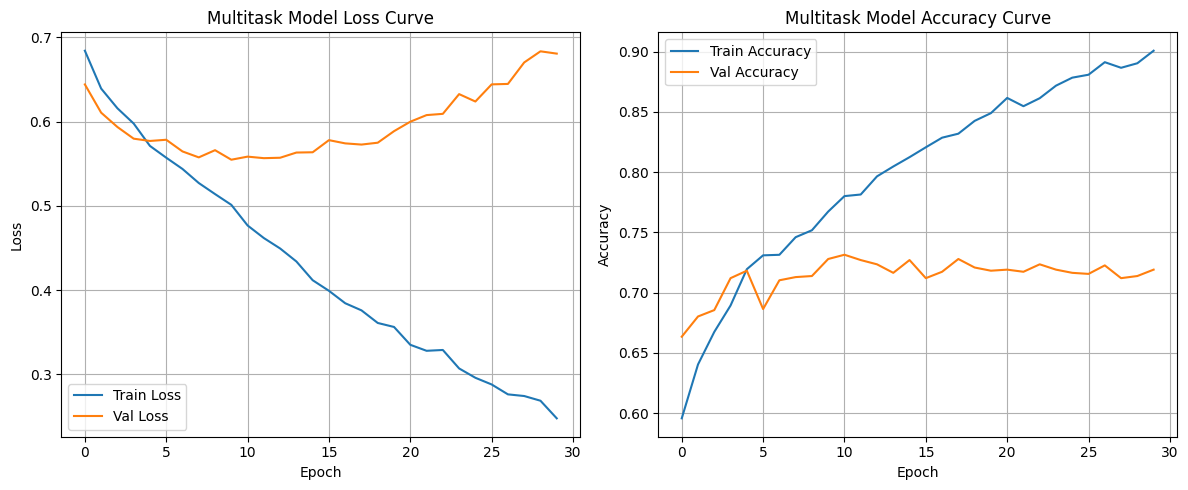

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# ----------------------
# 1) LOSS CURVE
# ----------------------
plt.subplot(1, 2, 1)
plt.plot(history_mt.history['loss'], label='Train Loss')
plt.plot(history_mt.history['val_loss'], label='Val Loss')
plt.title("Multitask Model Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# ----------------------
# 2) ACCURACY CURVE (binary_accuracy)
# ----------------------
plt.subplot(1, 2, 2)
plt.plot(history_mt.history['binary_accuracy'], label='Train Accuracy')
plt.plot(history_mt.history['val_binary_accuracy'], label='Val Accuracy')
plt.title("Multitask Model Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# 테스트 데이터 evalutae

## 1) 모델 전체 수준 평가 (binary_accuracy)
# keras가 계산하는 기본 metric으로 4개의 축 accuracy를 평균낸 값이다.
# 전체 test accuracy = axis-wise accuracy 평균
model_mt.evaluate(x_test, y_test)


## 2) 각 축별로 테스트
# mbti 축별로 개별 정확도를 계산하는 것
# 어던 축이 더 예측하기 어려운지를 판단할 수 있다.
pred = (model_mt.predict(x_test) > 0.5).astype(int)

ei_acc = (pred[:,0] == y_test[:,0]).mean()
sn_acc = (pred[:,1] == y_test[:,1]).mean()
ft_acc = (pred[:,2] == y_test[:,2]).mean()
pj_acc = (pred[:,3] == y_test[:,3]).mean()


## 3) 전체 mbti 정확도 (full accuracy)
# 실제 mbti에서 한글자라도 틀리면 0점
# 4개를 모두 맞아야 1점이다.
# 정확하게 mbti 문자열 전체를 맞춘 비율
# full accuracy = 0.32 -> 100명 중 32명은 mbti 전체를 맞춘 것

def combine_mbti(ei, sn, ft, pj):
    return (
        ("E" if ei==1 else "I") +
        ("N" if sn==1 else "S") +
        ("T" if ft==1 else "F") +
        ("J" if pj==1 else "P")
    )

pred_mbti = [combine_mbti(*row) for row in pred]

full_acc = (np.array(pred_mbti) == y_raw[idx_test]).mean()


## 4) partial accuracy
# 축 평균이 아닌 샘플 단위 평균을 구한다.
# 샘플 단위로 4축 중 몇개를 맞췄는지에 대한 평균값이다.
# partial accuracy = 0.72 -> 72%의 축은 부분적으로 맞춘 것

def partial_accuracy(pred_list, true_list):
    total = 0
    for p, t in zip(pred_list, true_list):
        total += sum([p[i] == t[i] for i in range(4)]) / 4
    return total / len(pred_list)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - binary_accuracy: 0.7316 - loss: 0.5504
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


### 모델평가 시각화

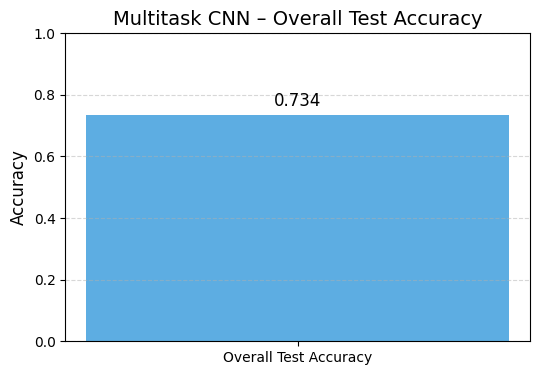

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


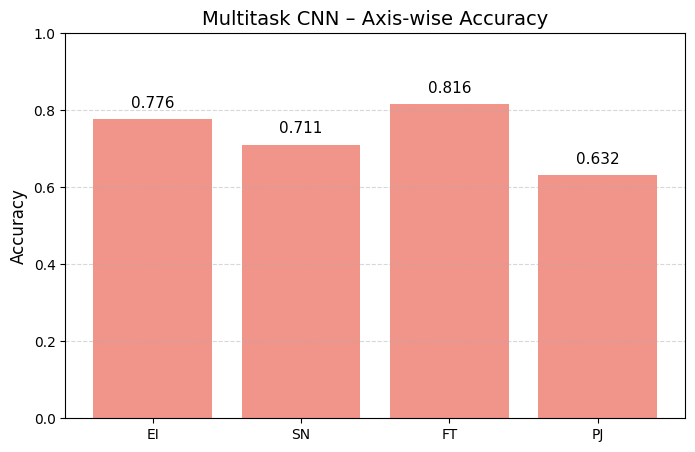

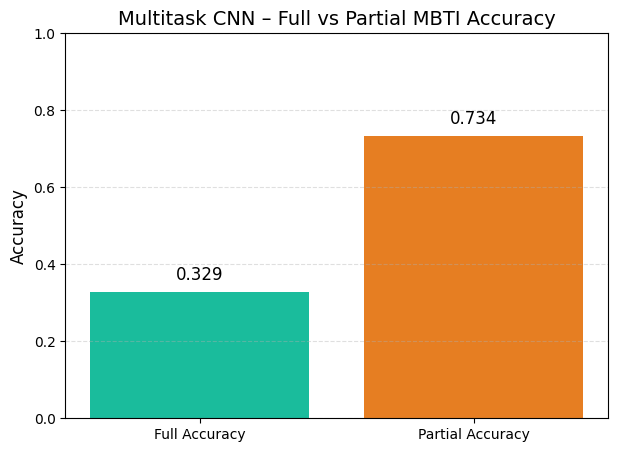

In [10]:
## 1) 전체 모델 평가
test_loss, test_acc = model_mt.evaluate(x_test, y_test, verbose=0)

plt.figure(figsize=(6,4))
plt.bar(["Overall Test Accuracy"], [test_acc], color="#5DADE2")
plt.ylim(0,1)
plt.title("Multitask CNN – Overall Test Accuracy", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 라벨 추가
plt.text(0, test_acc + 0.03, f"{test_acc:.3f}", ha='center', fontsize=12)

plt.show()


## 2) 축별 테스트
pred = (model_mt.predict(x_test) > 0.5).astype(int)

ei_acc = (pred[:,0] == y_test[:,0]).mean()
sn_acc = (pred[:,1] == y_test[:,1]).mean()
ft_acc = (pred[:,2] == y_test[:,2]).mean()
pj_acc = (pred[:,3] == y_test[:,3]).mean()

axis_names = ["EI", "SN", "FT", "PJ"]
axis_acc = [ei_acc, sn_acc, ft_acc, pj_acc]

plt.figure(figsize=(8,5))
bars = plt.bar(axis_names, axis_acc, color="#F1948A")
plt.ylim(0,1)
plt.title("Multitask CNN – Axis-wise Accuracy", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 정확도 표시
for i, v in enumerate(axis_acc):
    plt.text(i, v + 0.03, f"{v:.3f}", ha='center', fontsize=11)

plt.show()


## 3) Full

def combine_mbti_vec(pred_row):
    return (
        ("E" if pred_row[0]==1 else "I") +
        ("N" if pred_row[1]==1 else "S") +
        ("T" if pred_row[2]==1 else "F") +
        ("J" if pred_row[3]==1 else "P")
    )

pred_mbti = [combine_mbti_vec(row) for row in pred]
true_mbti = [combine_mbti_vec(row) for row in y_test]

# Full MBTI Accuracy
full_acc = (np.array(pred_mbti) == np.array(true_mbti)).mean()

## 4) Partial Accuracy
def partial_accuracy(pred_list, true_list):
    total = 0
    for p, t in zip(pred_list, true_list):
        total += sum([p[i] == t[i] for i in range(4)]) / 4
    return total / len(pred_list)

pacc = partial_accuracy(pred_mbti, true_mbti)

plt.figure(figsize=(7,5))
bars = plt.bar(
    ["Full Accuracy", "Partial Accuracy"],
    [full_acc, pacc],
    color=["#1ABC9C", "#E67E22"]
)
plt.ylim(0,1)
plt.title("Multitask CNN – Full vs Partial MBTI Accuracy", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 값 표기
plt.text(0, full_acc + 0.03, f"{full_acc:.3f}", ha='center', fontsize=12)
plt.text(1, pacc + 0.03, f"{pacc:.3f}", ha='center', fontsize=12)

plt.show()

### SHAP 적용하기

- Multitask CNN 모델에서 각 mbti 축에 영향을 주는 음악 특성이 무엇인지 분석한다.
- 즉, 왜 모델이 특정 mbti 축을 이렇게 예측했는지에 대한 힌트를 얻을 수 있다.

In [14]:
# Multitask SHAP 적용
import shap

## 1) background / sample 설정
#  - background: 기준 분포 (train 일부)
#  - sample: 설명하고 싶은 테스트 데이터 일부
x_background = x_train[:100]     # 필요하면 50~200 정도로 조절
x_sample     = x_test[:80]


## 2) GradientExplainer 사용 (Conv1D + multi-output 구조)
explainer_mt = shap.GradientExplainer(model_mt, x_background)


## 3) SHAP 값 계산
#   multi-output 모델이므로 output shape은 (batch,4)이다.
#   따라서, SHAP의 구조도, [samples, tracks=60, features=11, outputs=4]의 구조이다.
shap_values_mt = explainer_mt.shap_values(x_sample)

print("type(shap_values_mt):", type(shap_values_mt))
if isinstance(shap_values_mt, list):
    print("len(shap_values_mt):", len(shap_values_mt))
    print("shap_values_mt[0].shape:", shap_values_mt[0].shape)  # (samples, 60, 11) 예상
else:
    print("shap_values_mt.shape:", shap_values_mt.shape)


# numeric_features: ['tempo', 'loudness', ..., 'happiness']
# categorical_feature: 'mode'
# encoder: 'mode'를 one-hot 했던 OneHotEncoder
mode_categories = encoder.categories_[0]
mode_feature_names = [f"mode_{c}" for c in mode_categories]

feature_names = numeric_features + mode_feature_names  # 총 11개
print("feature_names:", feature_names)
print("len(feature_names):", len(feature_names))

axis_names = ["E/I", "N/S", "T/F", "J/P"]
impact_results_mt = {}

print("shap_values_mt.shape:", shap_values_mt.shape)  # (80, 60, 11, 4)

# 축별 SHAP 점수 계산
for axis_idx, axis_name in enumerate(axis_names):
    axis_shap = shap_values_mt[..., axis_idx]
    print(axis_name, "axis_shap.shape:", axis_shap.shape)

    feature_importance = np.mean(np.abs(axis_shap), axis=(0, 1))
    print(axis_name, "feature_importance.shape:", feature_importance.shape)

    # 상위 5개 feature index 선택
    top_idx = np.argsort(feature_importance)[::-1][:5]

    # (feature 이름, 중요도 값)
    top_features = [
        (feature_names[i], feature_importance[i]) for i in top_idx
    ]
    impact_results_mt[axis_name] = top_features


print("\n(Multitask 모델)축별(E/I, N/S, T/F, J/P) 영향력 높은 상위 5개 특성\n")
for axis_name, feats in impact_results_mt.items():
    print(f"{axis_name}:")
    for fname, score in feats:
        print(f" - {fname}: {score:.4f}")
    print("")



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(80, 60, 11))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 60, 11))']
  warnings.warn(msg)


type(shap_values_mt): <class 'numpy.ndarray'>
shap_values_mt.shape: (80, 60, 11, 4)
feature_names: ['tempo', 'loudness', 'danceability', 'energy', 'speechiness', 'acousticness', 'liveness', 'happiness', 'instrumentalness', 'mode_0.0', 'mode_1.0']
len(feature_names): 11
shap_values_mt.shape: (80, 60, 11, 4)
E/I axis_shap.shape: (80, 60, 11)
E/I feature_importance.shape: (11,)
N/S axis_shap.shape: (80, 60, 11)
N/S feature_importance.shape: (11,)
T/F axis_shap.shape: (80, 60, 11)
T/F feature_importance.shape: (11,)
J/P axis_shap.shape: (80, 60, 11)
J/P feature_importance.shape: (11,)

(Multitask 모델)축별(E/I, N/S, T/F, J/P) 영향력 높은 상위 5개 특성

E/I:
 - happiness: 0.0041
 - danceability: 0.0036
 - acousticness: 0.0027
 - speechiness: 0.0025
 - tempo: 0.0023

N/S:
 - acousticness: 0.0024
 - speechiness: 0.0023
 - happiness: 0.0022
 - danceability: 0.0021
 - liveness: 0.0019

T/F:
 - happiness: 0.0045
 - speechiness: 0.0042
 - acousticness: 0.0041
 - mode_1.0: 0.0031
 - tempo: 0.0026

J/P:
 - acous

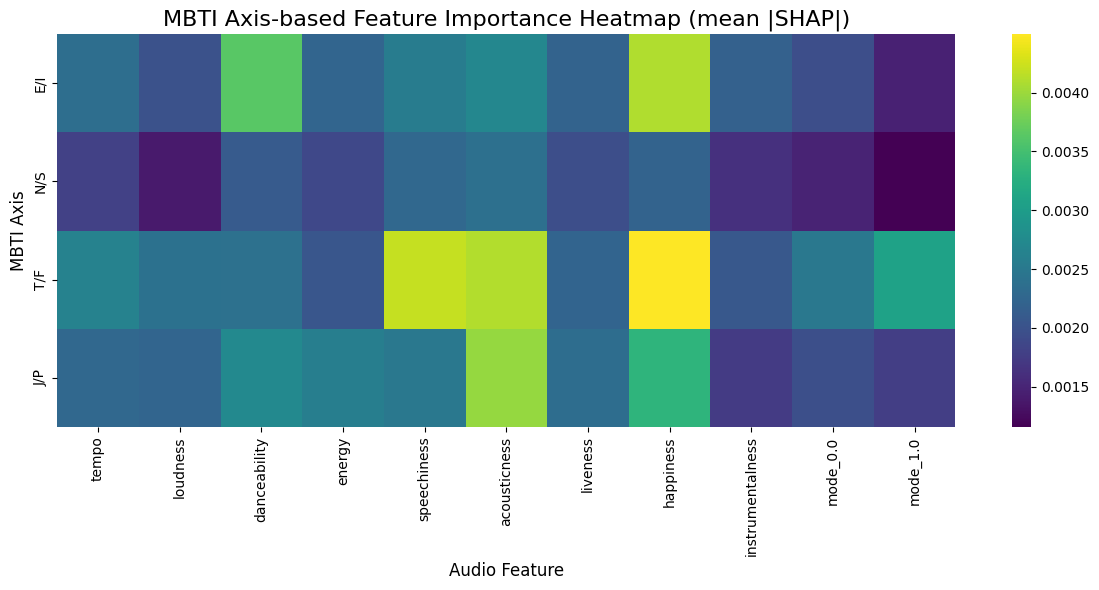

In [15]:
# SHAP을 heatmap으로 시각화하기

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

n_axes = len(axis_names)
n_features = len(feature_names)

axis_shap_mean = np.zeros((n_axes, n_features))

for axis_idx, axis_name in enumerate(axis_names):
    axis_shap = shap_values_mt[..., axis_idx]
    fi = np.mean(np.abs(axis_shap), axis=(0, 1))
    axis_shap_mean[axis_idx, :] = fi

df_heatmap = pd.DataFrame(
    axis_shap_mean,
    index=axis_names,
    columns=feature_names
)

plt.figure(figsize=(12, 6))
sns.heatmap(df_heatmap, cmap="viridis", annot=False)
plt.title("MBTI Axis-based Feature Importance Heatmap (mean |SHAP|)", fontsize=16)
plt.xlabel("Audio Feature", fontsize=12)
plt.ylabel("MBTI Axis", fontsize=12)
plt.tight_layout()
plt.show()



==== E/I summary plot ====



/tmp/ipython-input-2553460763.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


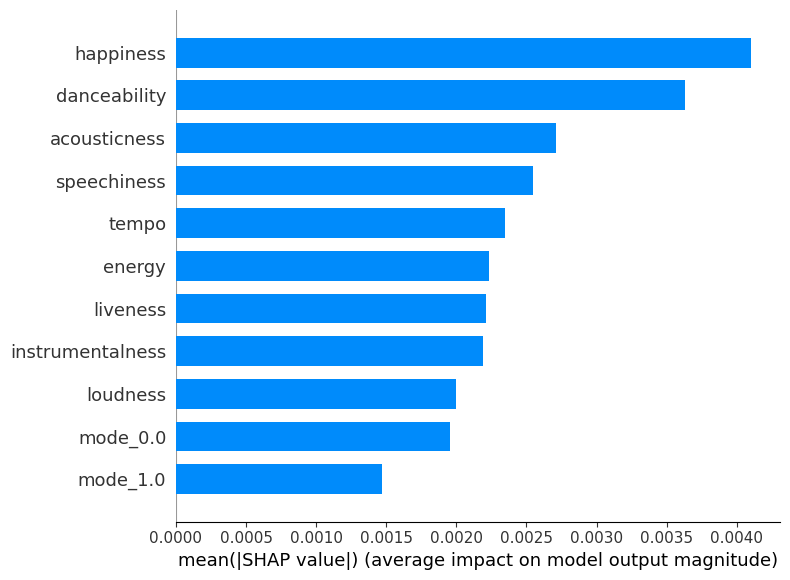


==== N/S summary plot ====



/tmp/ipython-input-2553460763.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


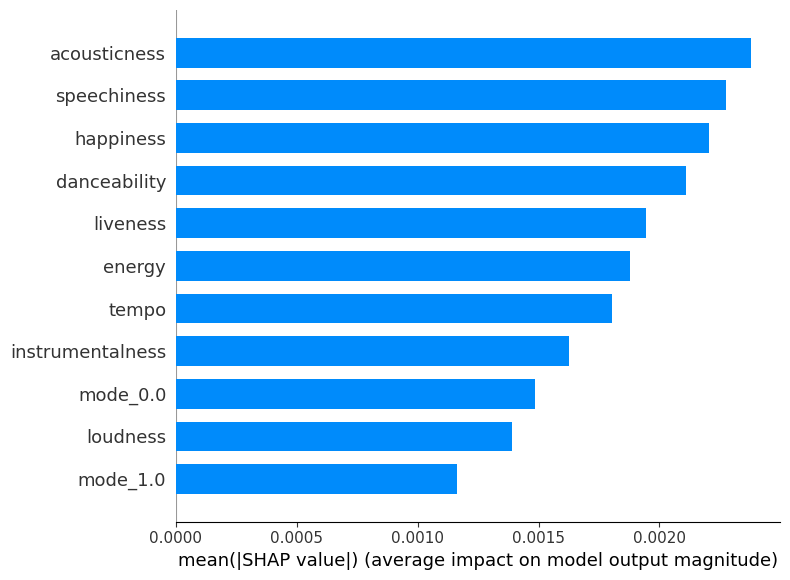


==== T/F summary plot ====



/tmp/ipython-input-2553460763.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


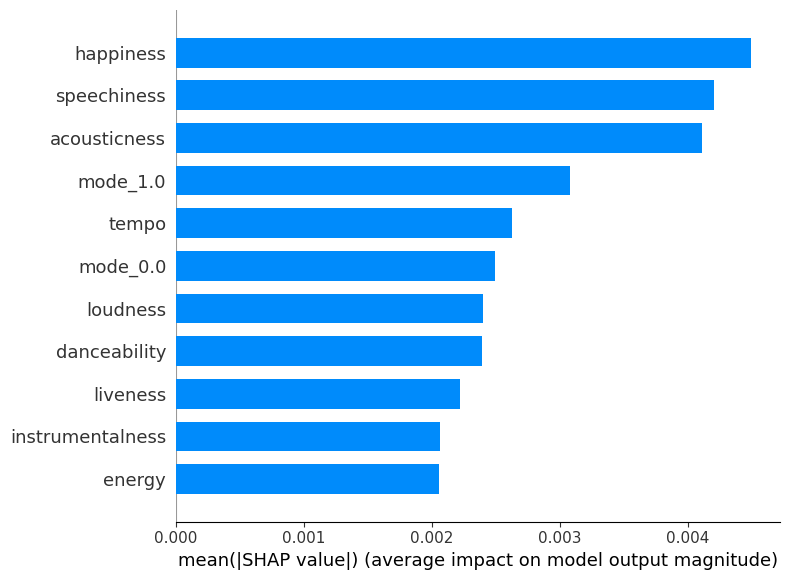


==== J/P summary plot ====



/tmp/ipython-input-2553460763.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


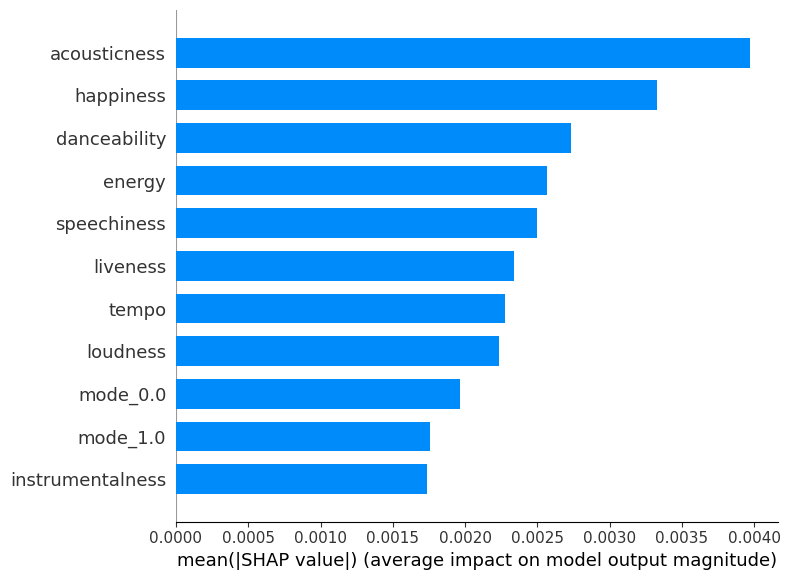

In [16]:
# SHAP을 summary plot으로 시각화

axis_names = ["E/I", "N/S", "T/F", "J/P"]

for axis_idx, axis_name in enumerate(axis_names):
    print(f"\n==== {axis_name} summary plot ====\n")

    # ① 해당 축 SHAP 슬라이싱
    axis_shap = shap_values_mt[..., axis_idx]   # (samples, 60, 11)

    # ② flatten (samples * tracks, features)
    axis_shap_flat = axis_shap.reshape(-1, axis_shap.shape[-1])
    x_sample_flat = x_sample.reshape(-1, x_sample.shape[-1])

    # ③ summary plot 그리기
    shap.summary_plot(
        axis_shap_flat,
        x_sample_flat,
        feature_names=feature_names,
        plot_type="bar",
        show=True
    )